In [1]:
def new_augment(image):
    augmented = []
    flips = [None, 0, 1, -1]  # no flip, vertical, horizontal, both
    rotations = [-15, 0, 15]  # degrees
    brightness = [-40, 0, 40]  # beta values
    contrast = [0.8, 1.0, 1.2]  # alpha values
    blur_kernels = [0, 3, 5]

    h, w = image.shape[:2]

    for flip in flips:
        if flip is not None:
            img = cv2.flip(image, flip)
        else:
            img = image.copy()

        for angle in rotations:
            M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1)
            rotated = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

            for b in brightness:
                bright = cv2.convertScaleAbs(rotated, alpha=1, beta=b)

                for c in contrast:
                    final = cv2.convertScaleAbs(bright, alpha=c, beta=0)
                    augmented.append(final)
                    blurred = cv2.GaussianBlur(image, (5, 5), 0)
                    augmented.append(blurred)
                    

    return augmented 


In [2]:
import os
import cv2
import numpy as np

def old_augment_image(image):
    augmented = []

    # Original
    augmented.append(image)

    # Flipped horizontally
    augmented.append(cv2.flip(image, 1))

    # Flipped vertically
    augmented.append(cv2.flip(image, 0))

    # # Rotate 90 degrees
    # rotated = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    # augmented.append(rotated)

    # Add Gaussian blur
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    augmented.append(blurred)

    # # 4. Rotate +15 degrees
    # angle = 15
    # h, w = image.shape[:2]
    # M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1)
    # rotated_15 = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    # augmented.append(rotated_15)

    # # 5. Rotate -15 degrees
    # M = cv2.getRotationMatrix2D((w / 2, h / 2), -15, 1)
    # rotated_minus_15 = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    # augmented.append(rotated_minus_15)

    # # 7. Increase brightness
    # brighter = cv2.convertScaleAbs(image, alpha=1, beta=40)
    # augmented.append(brighter)

    # # 8. Decrease brightness
    # darker = cv2.convertScaleAbs(image, alpha=1, beta=-40)
    # augmented.append(darker)

    # # 9. Increase contrast
    # high_contrast = cv2.convertScaleAbs(image, alpha=1.5, beta=0)
    # augmented.append(high_contrast)

    # # 10. Decrease contrast
    # low_contrast = cv2.convertScaleAbs(image, alpha=0.5, beta=0)
    # augmented.append(low_contrast)

    return augmented


In [3]:
import os
import cv2
import numpy as np

dataset_path = "Desktop/Digit_captures"

categories = ["LetterA", "LetterR", "Letter7"]

data = []
labels = []

IMAGE_SIZE = (64,64)

for category in categories:
    folder_path = os.path.join(dataset_path, category)

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)

        # Load image in grayscale
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        # image = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        # image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        # image = cv2.imread(img_path, cv2.IMREAD_ANYDEPTH)
        # image = cv2.imread(img_path, cv2.IMREAD_ANYCOLOR)
        # Read as 16-bit grayscale (if available)
        # image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)

        if image is None:
            print(f"Failed to load image {img_path}")
            continue

        # Resize
        image = cv2.resize(image, IMAGE_SIZE)

        # # Flatten image into 1D vector
        # flat = image.flatten()
        # data.append(flat)
        # labels.append(category)
        
        #making augmented images by flipping, rotating and playing with blur
        for img in new_augment(image):
            flat = image.flatten()
            data.append(flat)
            labels.append(category)

X = np.array(data)
y = np.array(labels)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (64800, 4096)
Shape of y: (64800,)


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Encoded labels:", y_encoded)


Classes: ['Letter7' 'LetterA' 'LetterR']
Encoded labels: [1 1 1 ... 0 0 0]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.9, random_state=42, stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 6480
Testing samples: 58320


In [12]:
from sklearn.tree import DecisionTreeClassifier

# Create classifier
clf = DecisionTreeClassifier(random_state=42)

# Train
clf.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
from sklearn.metrics import accuracy_score, classification_report

# Predict
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Detailed report
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 1.0
              precision    recall  f1-score   support

     Letter7       1.00      1.00      1.00     19440
     LetterA       1.00      1.00      1.00     19440
     LetterR       1.00      1.00      1.00     19440

    accuracy                           1.00     58320
   macro avg       1.00      1.00      1.00     58320
weighted avg       1.00      1.00      1.00     58320



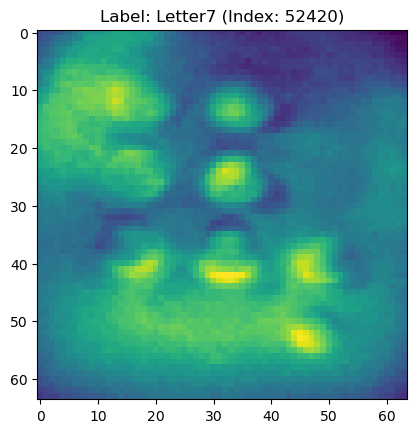

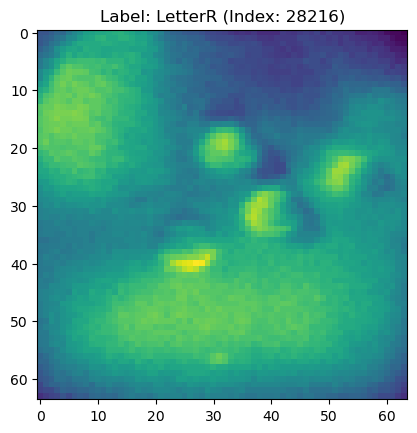

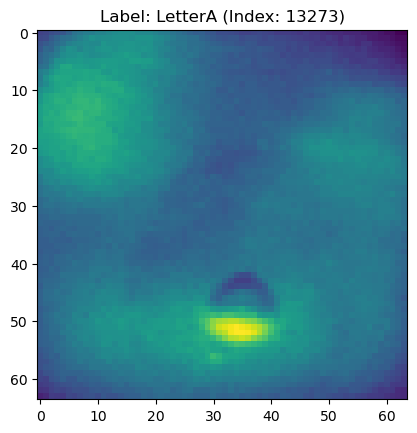

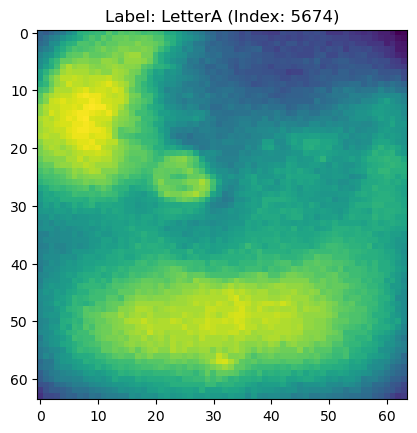

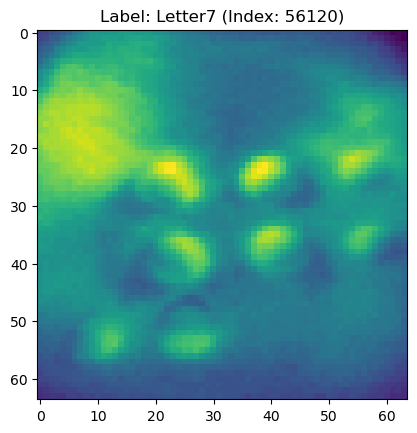

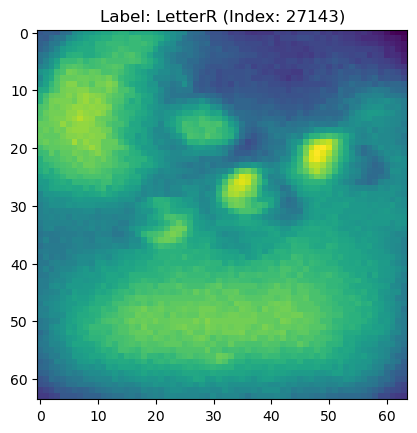

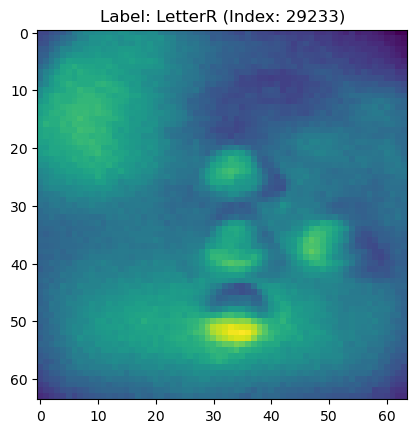

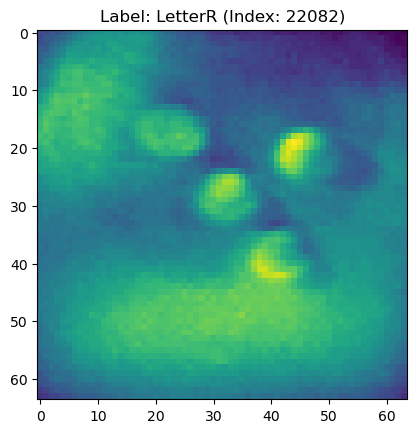

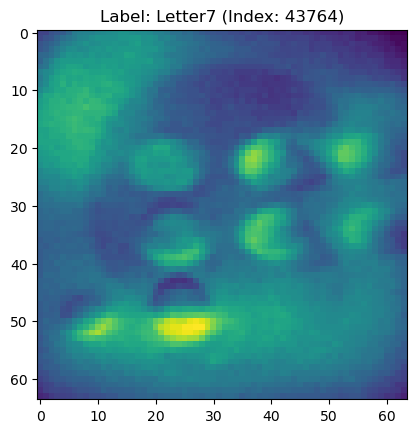

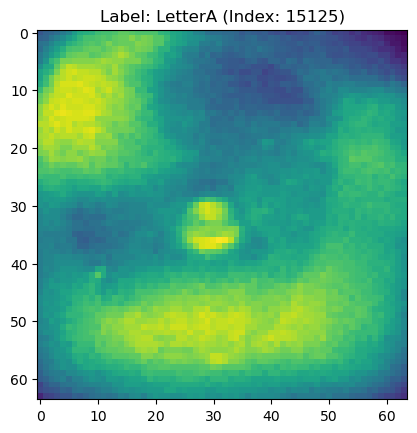

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming X is your image array and y is your label array
# IMAGE_SIZE should be defined (e.g., (28, 28) for MNIST)

# Generate 10 random indices
random_indices = np.random.choice(len(X), 10, replace=False)

# Display each random image
for idx in random_indices:
    img = X[idx].reshape(IMAGE_SIZE)
    plt.imshow(img)
    plt.title(f"Label: {y[idx]} (Index: {idx})")
    plt.show()